# Prédiction de routes aériennes (Link Prediction) avec des GNN
**Problématique** : comment exploiter simultanément les caractéristiques des aéroports (localisation, pays, population) et la structure du réseau aérien pour prédire l'existence de routes non observées ?

**Cadre** : on reste sur un VGAE et on fait varier ses deux briques :
`X, A --ENCODEUR (GCN / GraphSAGE / GAT)--> z --DECODEUR (produit scalaire / MLP / MLP + distance)--> score(u,v)`

**Protocole** : `RandomLinkSplit` en train / validation (5 %) / test (10 % puis 20 %), 5 graines.
La validation sert à choisir le meilleur epoch, les hyperparamètres et le meilleur couple (encodeur, décodeur) ; le test n'est utilisé qu'à la fin.

Tout le code est dans `src/` (voir README pour la répartition par membre).

In [ ]:
import sys
sys.path.append("..")         

from src.data import load_graph, graph_to_tensors, make_data
from src.features import build_features
from src.gnn_models import build_model
from src.training import train_model, test_model
from src.evaluation import (split_data, select_hyperparams, run_all, make_table, fit_final,
                            suspicious_links, CONVS, DECS, DEC_LABEL, GRID_NAMES)
from src.plots import plot_comparison, plot_grid, plot_training_curves

c:\Users\test\Downloads\airline_link_prediction\airline_link_prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\test\Downloads\airline_link_prediction\airline_link_prediction\.venv\Lib\site-packages\torch\jit\_script.py:1485: FutureWarning: `torch.jit.script` is not supported in Python 3.14+ and may break. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


## 1. Données 

In [ ]:
G = load_graph("../data/airports.graphml")     
edge_index, info = graph_to_tensors(G)
print(G)
print("liens (dans les 2 sens) :", edge_index.shape[1])

Graph with 3363 nodes and 13547 edges
liens (dans les 2 sens) : 27094


In [3]:
x_full = build_features(info)
data = make_data(x_full, edge_index)
print(data)

Data(x=[3363, 216], edge_index=[2, 27094])


## 2. Split train / validation / test 

In [4]:
train_d, val_d, test_d = split_data(data, test_ratio=0.10, seed=0)
print("train :", train_d.pos_edge_label_index.shape[1], "liens positifs")
print("val   :", val_d.pos_edge_label_index.shape[1], "positifs /", val_d.neg_edge_label_index.shape[1], "negatifs")
print("test  :", test_d.pos_edge_label_index.shape[1], "positifs /", test_d.neg_edge_label_index.shape[1], "negatifs")

train : 11516 liens positifs
val   : 677 positifs / 677 negatifs
test  : 1354 positifs / 1354 negatifs


## 3. Un premier entraînement : VGAE GCN + produit scalaire (Membre 2)

meilleur AUC validation : 0.9867
test : AUC = 0.9879  AP = 0.9896


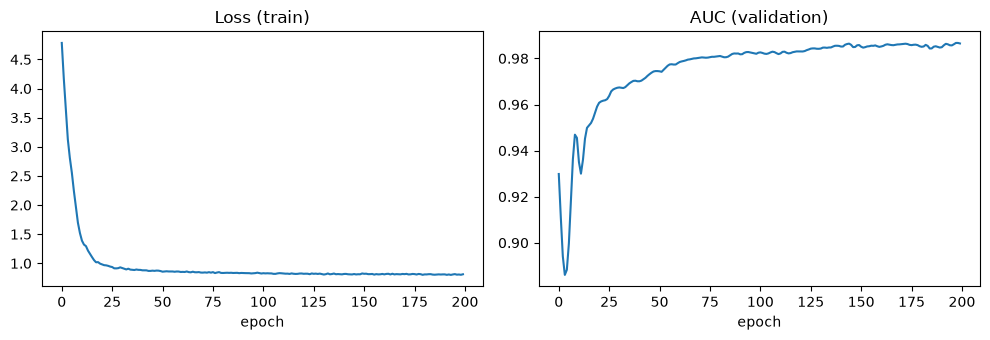

In [5]:
model = build_model(x_full.shape[1], hidden=64, out_dim=32, n_layers=2, variational=True,
                    conv="gcn", decoder="dot")
out = train_model(model, train_d, val_d, epochs=200, variational=True, lr=0.01)
print("meilleur AUC validation :", round(out["best_val_auc"], 4))
auc, ap = test_model(model, test_d)
print(f"test : AUC = {auc:.4f}  AP = {ap:.4f}")
plot_training_curves(out["history"])

## 4. Hyperparamètres choisis sur la validation 

In [6]:
grid = {"hidden": [32, 64], "out": [16, 32], "lr": [0.01, 0.005]}
best_hp, df_hp = select_hyperparams(edge_index, info, grid, ratio=0.10, seeds=(0, 1))
print(df_hp)
print("hyperparamètres retenus :", best_hp)

   hidden  out     lr   val_auc
0      64   16  0.010  0.988390
1      32   32  0.010  0.987454
2      64   32  0.010  0.987231
3      32   16  0.010  0.984200
4      32   16  0.005  0.983461
5      64   16  0.005  0.983271
6      64   32  0.005  0.982466
7      32   32  0.005  0.980398
hyperparamètres retenus : {'hidden': 64, 'out': 16, 'lr': 0.01}


## 5. Expériences
- **Étape 1** : baselines (Adamic-Adar, MLP) + grille 3 × 3 encodeur × décodeur.
- Le meilleur couple est choisi sur l'**AUC de validation**.
- **Étape 2** : ablation de ce meilleur modèle (on retire un élément à la fois).

In [7]:
ratios = (0.10, 0.20)
results, meta = run_all(edge_index, info, ratios=ratios, seeds=(0, 1, 2, 3, 4), hp=best_hp)
print("Meilleur modèle :", meta["best_name"])

[etape 1] ratio 0.1 termine
[etape 1] ratio 0.2 termine
meilleur modele (AUC validation) : VGAE GCN + MLP
[etape 2] ratio 0.1 termine
[etape 2] ratio 0.2 termine
Meilleur modèle : VGAE GCN + MLP


In [ ]:
table, mean, std = make_table(results, ratios, meta["rows"])
print(table.to_markdown())      

|                                    | ('10% caches', 'AUC')   | ('10% caches', 'AP')   | ('20% caches', 'AUC')   | ('20% caches', 'AP')   |
|:-----------------------------------|:------------------------|:-----------------------|:------------------------|:-----------------------|
| Adamic-Adar (structure seule)      | 0.939 ± 0.002           | 0.940 ± 0.002          | 0.920 ± 0.003           | 0.921 ± 0.003          |
| MLP (features seules, sans graphe) | 0.965 ± 0.002           | 0.966 ± 0.003          | 0.965 ± 0.002           | 0.966 ± 0.002          |
| VGAE GCN + produit scalaire        | 0.986 ± 0.001           | 0.987 ± 0.001          | 0.985 ± 0.001           | 0.986 ± 0.000          |
| VGAE GCN + MLP                     | 0.990 ± 0.001           | 0.990 ± 0.002          | 0.987 ± 0.001           | 0.989 ± 0.001          |
| VGAE GCN + MLP + distance          | 0.989 ± 0.002           | 0.991 ± 0.002          | 0.987 ± 0.002           | 0.988 ± 0.002          |
| VGAE SAGE +

In [ ]:
for n, v in sorted(meta["val_auc"].items(), key=lambda t: -t[1]):
    print(f"{v:.4f}  {n}")

0.9894  VGAE GCN + MLP
0.9891  VGAE GCN + MLP + distance
0.9867  VGAE GCN + produit scalaire
0.9831  VGAE GAT + MLP + distance
0.9804  VGAE GAT + MLP
0.9665  VGAE SAGE + MLP + distance
0.9632  VGAE GAT + produit scalaire
0.9631  VGAE SAGE + produit scalaire
0.9578  VGAE SAGE + MLP


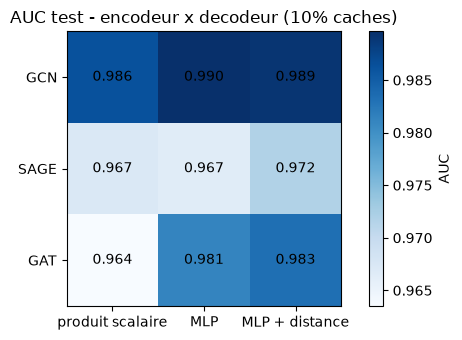

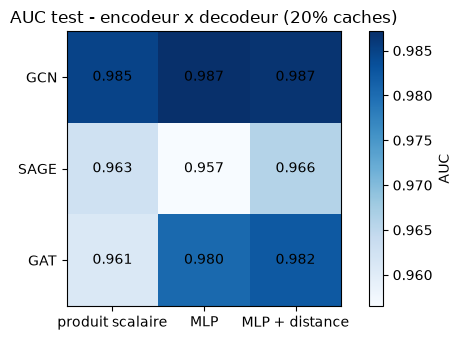

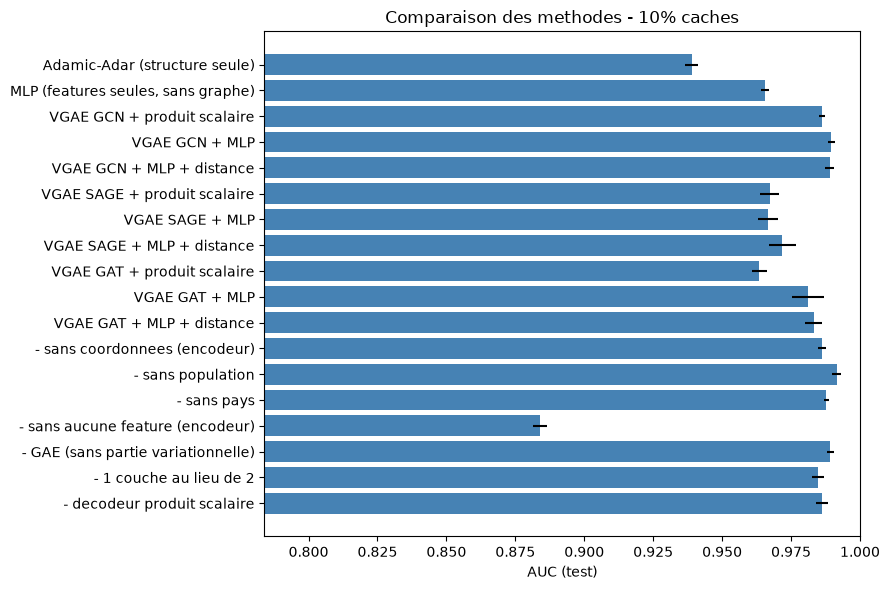

In [10]:
plot_grid(mean, GRID_NAMES, CONVS, DECS, DEC_LABEL, "10% caches", "AUC")
plot_grid(mean, GRID_NAMES, CONVS, DECS, DEC_LABEL, "20% caches", "AUC")
plot_comparison(mean, std, "10% caches", "AUC")

## 6. Bonus : liens existants les moins probables (candidats à des liens erronés)

In [11]:
model, splits, _ = fit_final(meta["best_cfg"], edge_index, info, hp=best_hp, ratio=0.10, seed=0)
suspicious_links(model, splits[0], info, k=15)

,ville_1,pays_1,ville_2,pays_2,score
0,Vancouver,CANADA,Anahim Lake,AUSTRALIA,0.012247
1,Pittsburgh,USA,Cumberland,AUSTRALIA,0.290798
2,New York,USA,Anchorage,USA,0.341357
3,Bangkok,THAILAND,Antalya,TURKEY,0.376014
4,Fort Lauderdale,USA,Quebec,CANADA,0.409724
5,Long Beach,USA,Lake Tahoe,USA,0.423386
6,Pittsburgh,USA,Hamilton,CANADA,0.432370
7,Shannon,IRELAND,Minsk,BELARUS,0.448936
8,Harbin,CHINA,Khabarovsk,RUSSIA,0.450844
9,Mexico City,M&Eacute;XICO#MEXICO,San Cristobal de Las Casas,PHILIPPINES,0.493093
